### This notebook shows example of plots and visualization
Supported file formats for saving the plots:   png, pdf, svg

In [3]:
import PyVisualFields
print(PyVisualFields.__file__)
print(PyVisualFields.__version__)

/home/eslamim/Partners HealthCare Dropbox/Mohammad Eslami/GithubRepos/PyVisualField/src/PyVisualFields/__init__.py
2.0.4


### plotValues() 
Plots/saves values in the specific shape (from vfprogression package)

This function plots the input VF values, sensitivity, td or pd. In addition, the functions can save the plot in the working directory as filename (e.g. 'td' in this example) with the defined format (e.g. 'png' in this example)

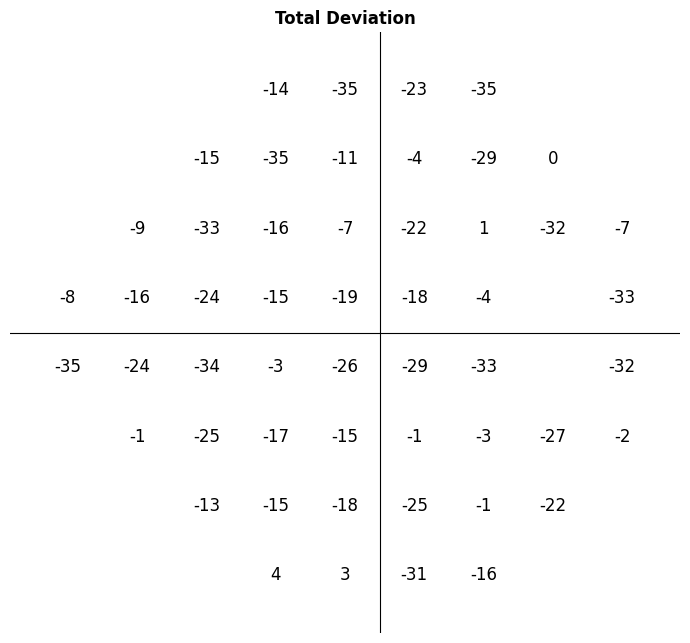

In [4]:
from PyVisualFields import vfprogression
import numpy as np
# this function expects some values, not a dataframe
td = np.random.randint(low=-35, high=5, size=(54,))
vfprogression.plotValues(td, title= 'Total Deviation',
                                 save=True, filename='td', fmt='png', show=True)

### plotProbabilities
plot/save probabilty e.g. tdp, pdp (from vfprogression package)

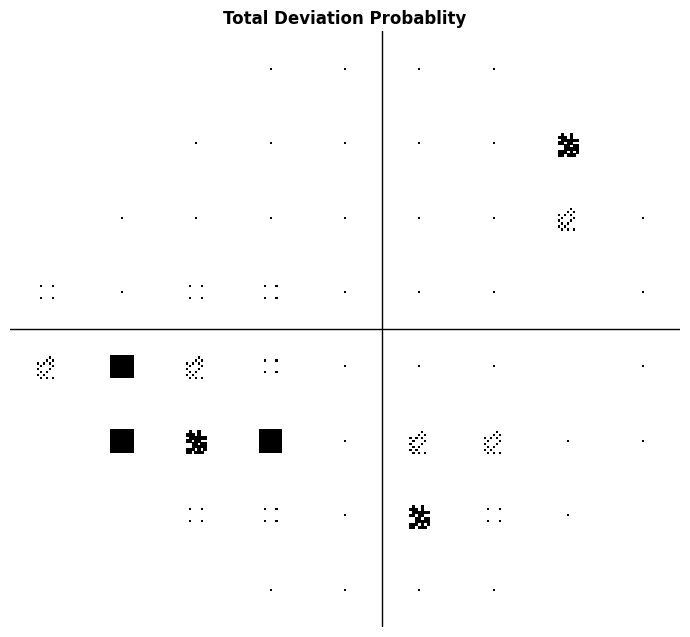

In [5]:
from PyVisualFields import vfprogression
from PyVisualFields.utils import canonicalize_vf_df, canonicalize_vf_row
import numpy as np

df_VFs_py = canonicalize_vf_df(vfprogression.data_vfseries())

vf = df_VFs_py.iloc[[5]] # get a one VF
ind_tdp_start= vf.columns.get_loc("tdp1")
ind_tdp_end= vf.columns.get_loc("tdp54") 
tdp = vf.iloc[0, ind_tdp_start:ind_tdp_end+1].to_numpy().astype(np.float16())

#this function also needs values, not dataframe
vfprogression.plotProbabilities(tdp, title= 'Total Deviation Probablity',
                                 save=True, filename='tdp', fmt='png', show=True)  

### Another example:
In this example, we derive the data of vfpwgRetest24d2() function (from visualFields package) and make it compatible with vfprogression packag to make the plot.

 Steps: canonicalization, compute missing blocks, and values
 

---> blocks {'sens': True, 'td': False, 'pd': False, 'tdp': False, 'pdp': False}
---> missed blocks ['td', 'pd', 'tdp', 'pdp']
---> missed blocks []


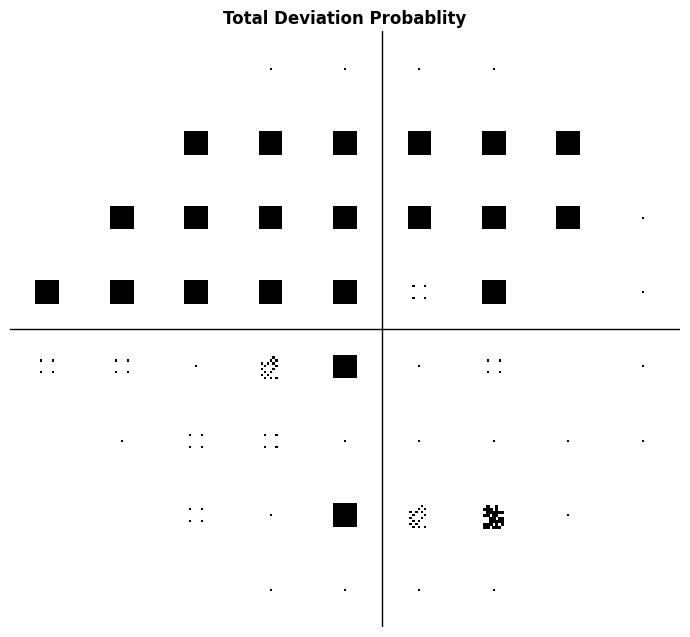

In [6]:
from PyVisualFields import visualFields
from PyVisualFields import vfprogression
from PyVisualFields.utils import canonicalize_vf_df, canonicalize_vf_row
from PyVisualFields.utils import vf_blocks, missing_blocks
from PyVisualFields.utils import compute_missing_blocks

df_VFs_py = canonicalize_vf_df(visualFields.data_vfpwgRetest24d2())
print('---> blocks',vf_blocks(df_VFs_py))
print('---> missed blocks', missing_blocks(df_VFs_py))

df_VFs = compute_missing_blocks(df_VFs_py)
print('---> missed blocks', missing_blocks(df_VFs))

ind_start=df_VFs.columns.get_loc("tdp1")
ind_end=df_VFs.columns.get_loc("tdp54") 

#df_td = df_td.fillna(0)
#df_tdp = df_tdp.fillna(0)

tdp = df_VFs.iloc[0, ind_start:ind_end+1].to_numpy().astype(np.float16())
vfprogression.plotProbabilities(tdp, title= 'Total Deviation Probablity',
                                 save=True, filename='tdp', fmt='png', show=True) 

### vfplot
plots a single visual field test (from visualFields package)

based on the input type, it can plot sensitivity(s), td, pd, tds (td & s), pds (pd & s) 
deviations maps are colorful and the colormap can be accessed by plotProbColormap

Description: vfplot function also saves the photo with filename (e.g. 'file' in this example) with the format (e.g. 'png' in this example.). 

---> missed blocks []


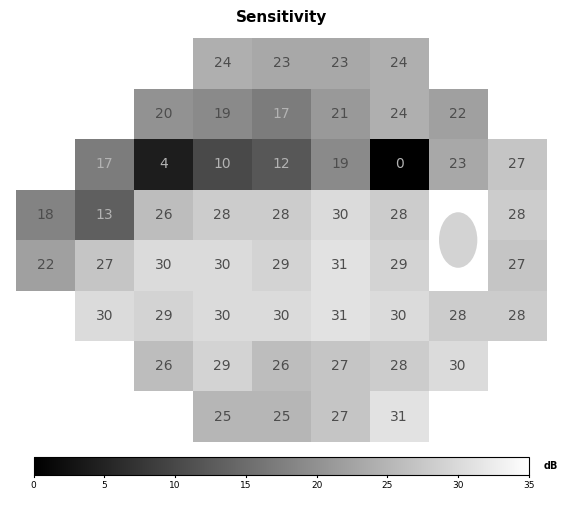

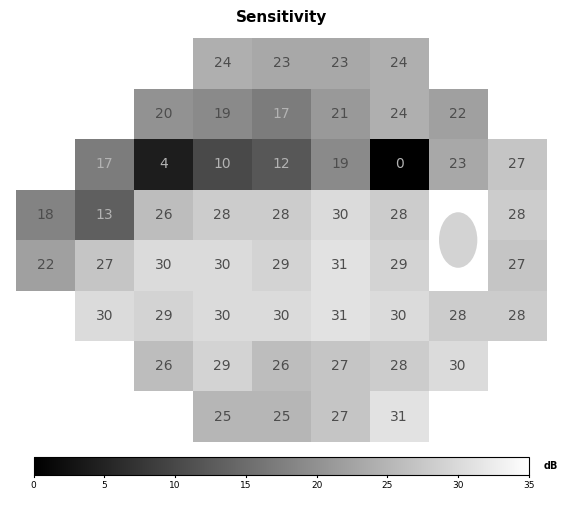

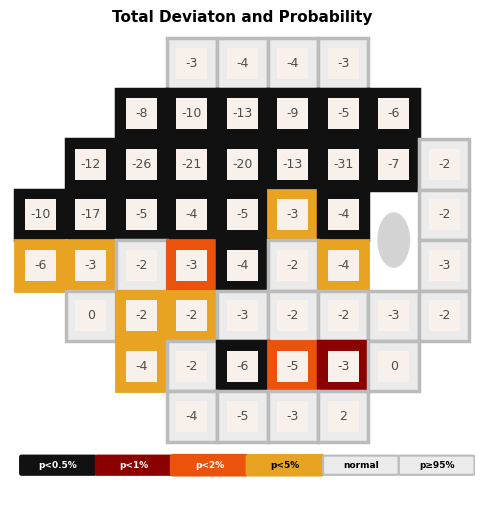

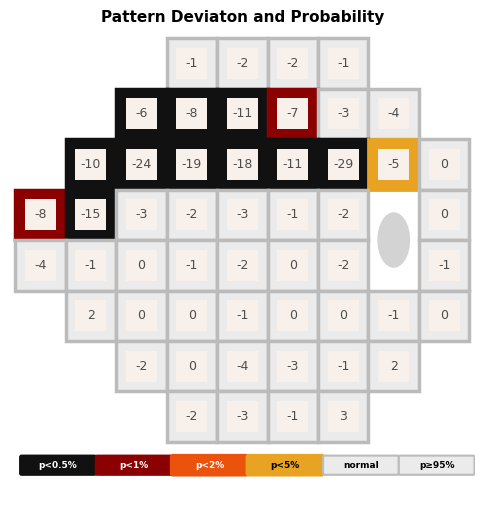

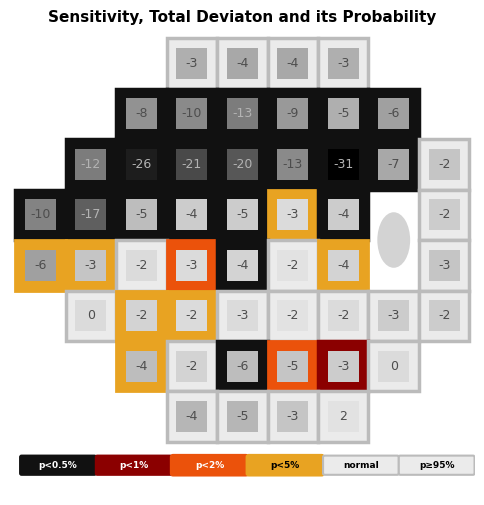

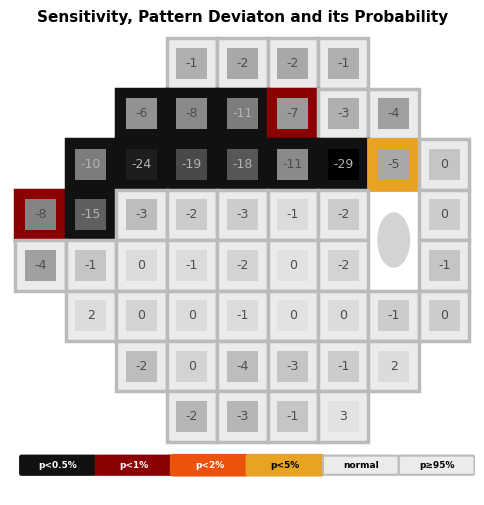

In [7]:
from PyVisualFields import visualFields
from PyVisualFields.utils import vf_blocks, missing_blocks
from PyVisualFields.utils import compute_missing_blocks
from PyVisualFields.utils import canonicalize_vf_df, canonicalize_vf_row


df_VFs_py = canonicalize_vf_df(visualFields.data_vfpwgRetest24d2()) #df_VFs_py is acquired using vfpwgRetest24d2() function. 
df_VFs = compute_missing_blocks(df_VFs_py)
print('---> missed blocks', missing_blocks(df_VFs))
vf = df_VFs.iloc[[0]] #lets pick the first VF of df_VFs_py as example

visualFields.vfplot(vf, type='s', title='Sensitivity', save=True, 
                    filename='file', fmt='png', show=True) # types: s, td,pd, tds, pds
visualFields.vfplot_s(vf, title='Sensitivity', save=True, 
                      filename='file', fmt='png', show=True) # types: s, td,pd, tds, pds
visualFields.vfplot_td(vf, title='Total Deviaton and Probability', save=True, 
                       filename='td', fmt='png', show=True) # alias for vfplot(type='td')
visualFields.vfplot_pd(vf, title='Pattern Deviaton and Probability', save=True, 
                       filename='pd', fmt='pdf', show=True) # alias for vfplot(type='pd')
visualFields.vfplot_tds(vf, title='Sensitivity, Total Deviaton and its Probability', 
                        save=True, filename='tds', fmt='png', show=True) # alias for vfplot(type='tds')
visualFields.vfplot_pds(vf, title='Sensitivity, Pattern Deviaton and its Probability', 
                        save=True, filename='pds', fmt='png', show=True) # alias for vfplot(type='pds')

# visualFields.plotProbColormap(save=True, filename='cmap', fmt='png') # show colormap of probablies (from visualFields package)

### Fn_report: Single Field Reporting 

Description: Generates a one-page report of single field analyses.

In [ ]:
from PyVisualFields import visualFields
from PyVisualFields.utils import vf_blocks, missing_blocks
from PyVisualFields.utils import compute_missing_blocks
from PyVisualFields.utils import canonicalize_vf_df, canonicalize_vf_row
from PyVisualFields.utils import Fn_report
import pandas as pd

df_VFs_py = canonicalize_vf_df(visualFields.data_vfpwgRetest24d2())#df_VFs_py is acquired using vfpwgRetest24d2() function. 
df_VFs_py = compute_missing_blocks(df_VFs_py)
df_gi = visualFields.getgl(df_VFs_py) # get global indices
combined_df = pd.concat([df_VFs_py, df_gi], axis=1)
final_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
vf = final_df.iloc[[0]]#get one eye's VF data

Fn_report(vf, 'report2.pdf')

==> py_getgl: missing global indices to compute: ['msens', 'ssens', 'tmd', 'tsd', 'pmd', 'psd', 'gh', 'vfi']
Saved report to report2.pdf


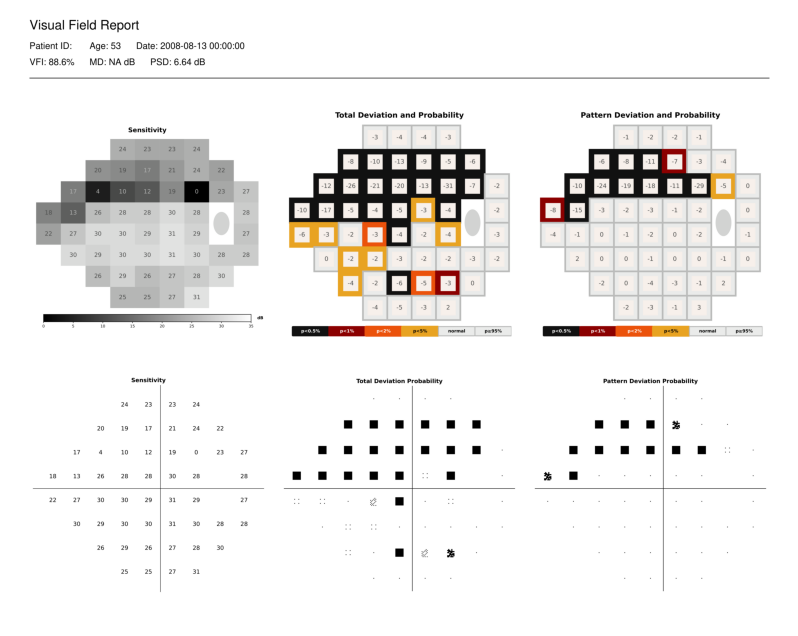

In [9]:
# the PDF high-quality file is already saved
# if you want a preview, just load it

import fitz
import matplotlib.pyplot as plt
import numpy as np

doc = fitz.open('report2.pdf')
page = doc[0]
pix = page.get_pixmap(dpi=500)

img = np.frombuffer(pix.samples, dtype=np.uint8)
img = img.reshape(pix.height, pix.width, pix.n)

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

### vfplotsparklines
Plot sparklines (from visualFields package)

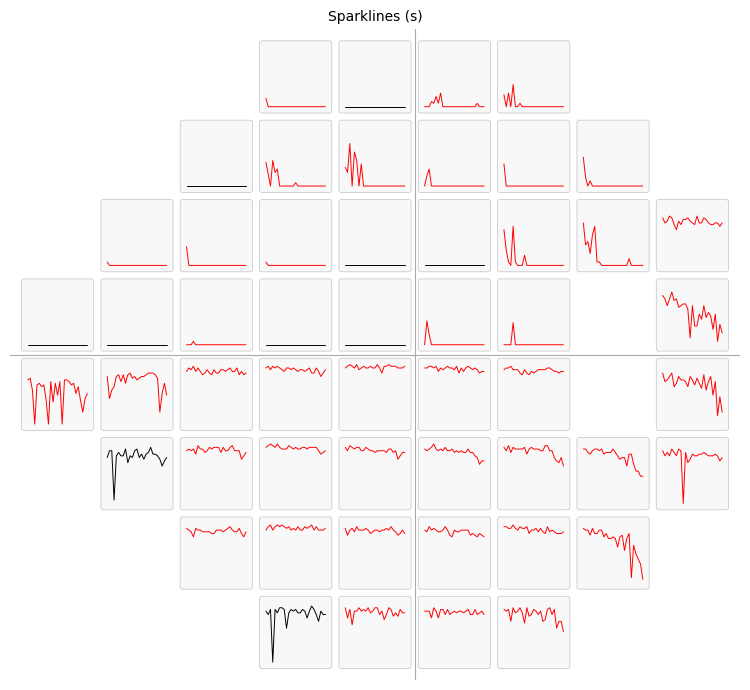

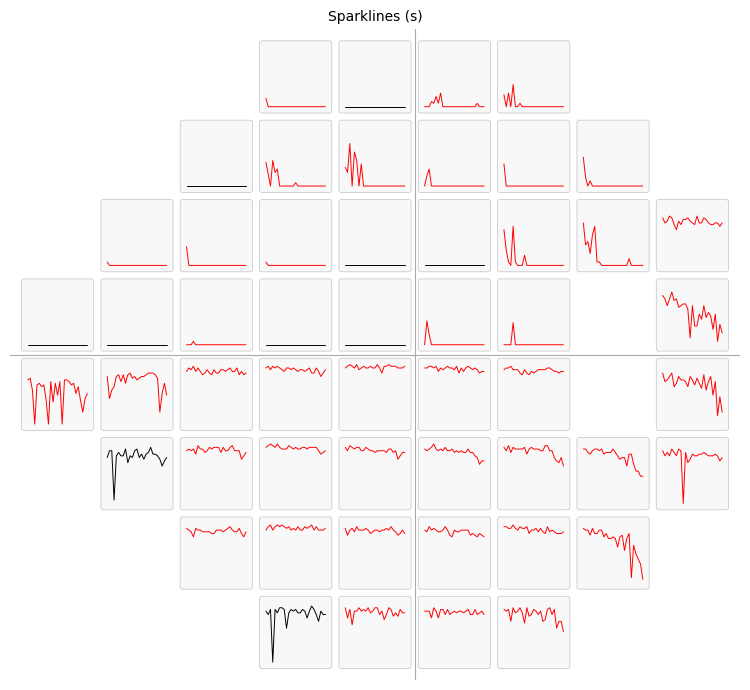

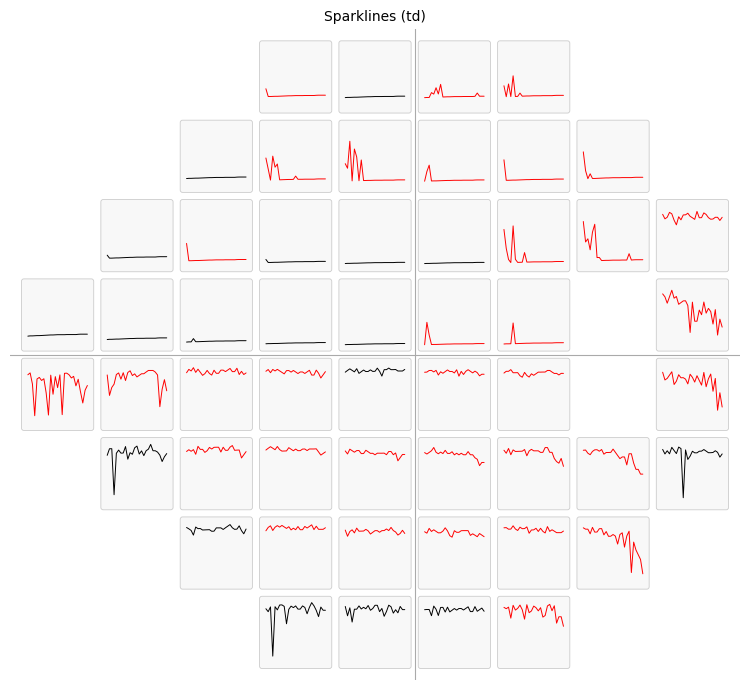

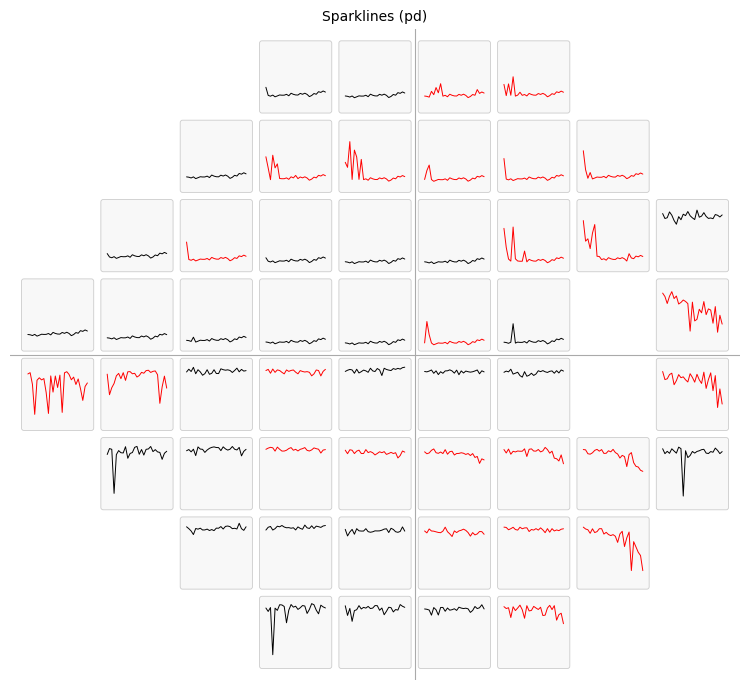

In [10]:
from PyVisualFields import visualFields
from PyVisualFields.utils import vf_blocks, missing_blocks
from PyVisualFields.utils import compute_missing_blocks
from PyVisualFields.utils import canonicalize_vf_df, canonicalize_vf_row

df_VFs_py = canonicalize_vf_df(visualFields.data_vfpwgSunyiu24d2())#df_VFs_py is acquired using vfpwgRetest24d2() function.

df_VFs_py = compute_missing_blocks(df_VFs_py)

filter1 = df_VFs_py.patientid=='sample1'
filter2 = df_VFs_py.eyeid=='OD'
df_vf_1 = df_VFs_py.loc[ filter1 & filter2]

visualFields.vfplotsparklines(df_vf_1, type='s', save=True, filename='file', fmt='png') # types: s, td, pd 
visualFields.vfplotsparklines_s(df_vf_1, save=True, filename='file', fmt='png') # alias for vfplotsparklines(type='s')
visualFields.vfplotsparklines_td(df_vf_1, save=True, filename='file', fmt='png')# alias for vfplotsparklines(type='td')
visualFields.vfplotsparklines_pd(df_vf_1, save=True, filename='file', fmt='png')# alias for vfplotsparklines(type='pd')

### vfplotplr 
plots the results of pointwise linear regression for a series of visual fields for an eye from a subject. (from visualFields package).

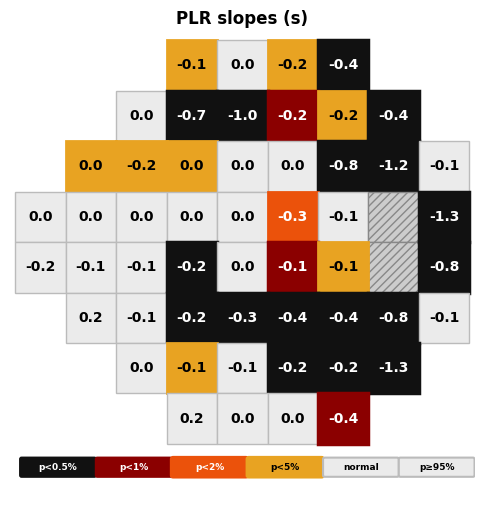

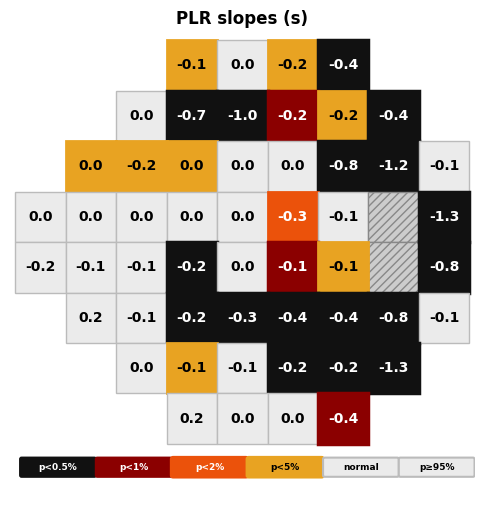

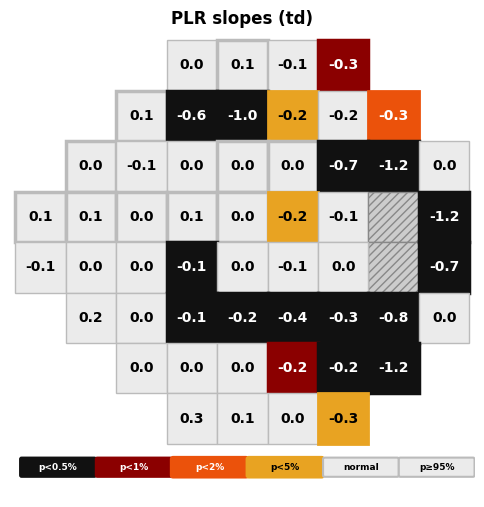

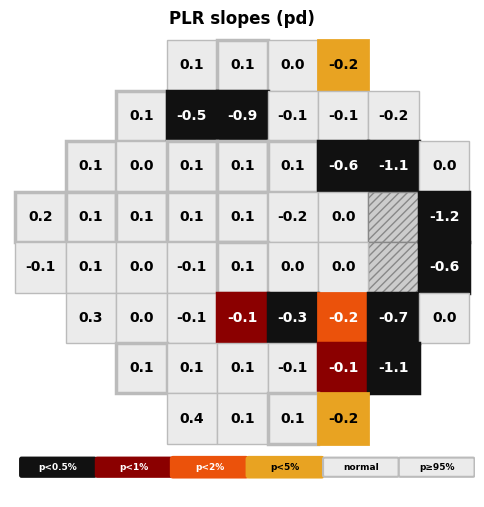

In [11]:
from PyVisualFields import visualFields
from PyVisualFields.utils import vf_blocks, missing_blocks
from PyVisualFields.utils import compute_missing_blocks
from PyVisualFields.utils import canonicalize_vf_df, canonicalize_vf_row


df_VFs_py = canonicalize_vf_df(visualFields.data_vfpwgSunyiu24d2())#df_VFs_py data is acquired using vfpwgRetest24d2() function.
df_VFs_py = compute_missing_blocks(df_VFs_py)

filter1 = df_VFs_py.patientid=='sample1'
filter2 = df_VFs_py.eyeid=='OD'
df_vf_1 = df_VFs_py.loc[ filter1 & filter2]


"""
The displayed number inside each cell = PLR slope
usually dB/year
The cell color = significance/confidence of progression or improvement
colors are based on the statistical significance (p-values) of the pointwise linear regression slopes
"""

visualFields.vfplotplr(df_vf_1, type='s', save=True, filename='file', fmt='png') # types: s, td, pd
visualFields.vfplotplr_s(df_vf_1, save=True, filename='file', fmt='png') # alias for vfplotplr(type='s')
visualFields.vfplotplr_td(df_vf_1, save=True, filename='file', fmt='png') # alias for vfplotplr(type='td')
visualFields.vfplotplr_pd(df_vf_1, save=True, filename='file', fmt='png') # alias for vfplotplr(type='pd')

### vflegoplot  
The legoplot shows the differences between the average values of visual field tests taken as baseline and those at the end of follow up (from visualFields package). 

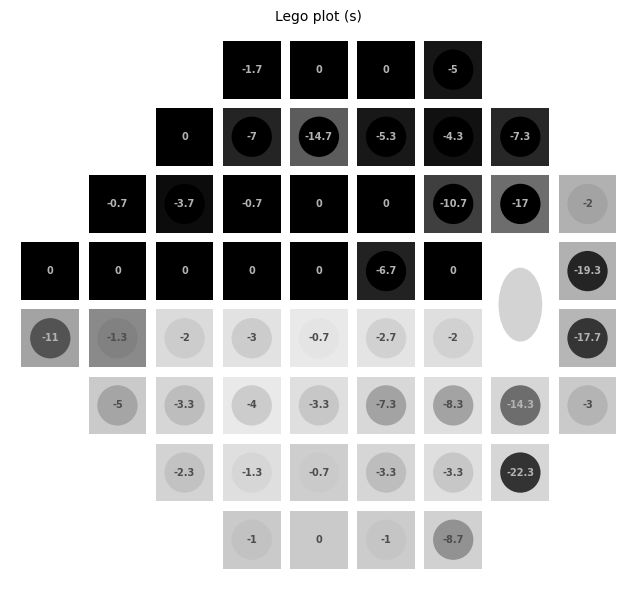

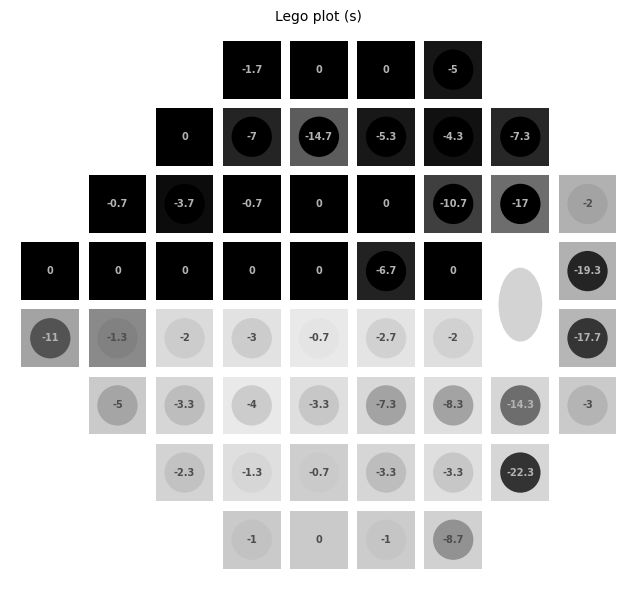

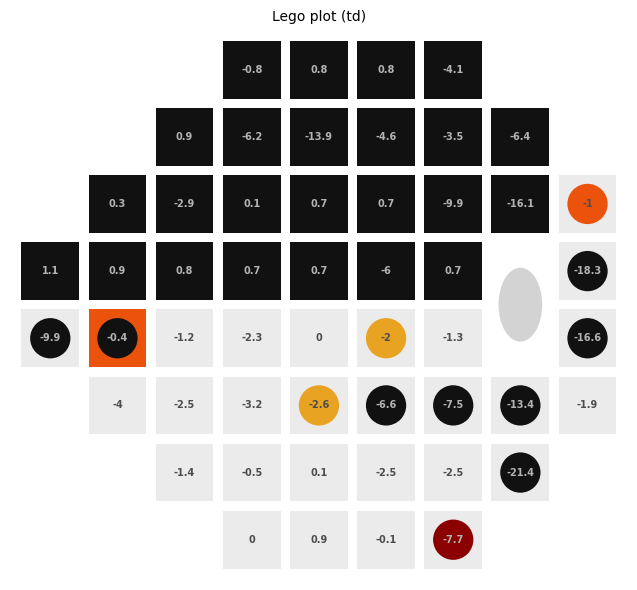

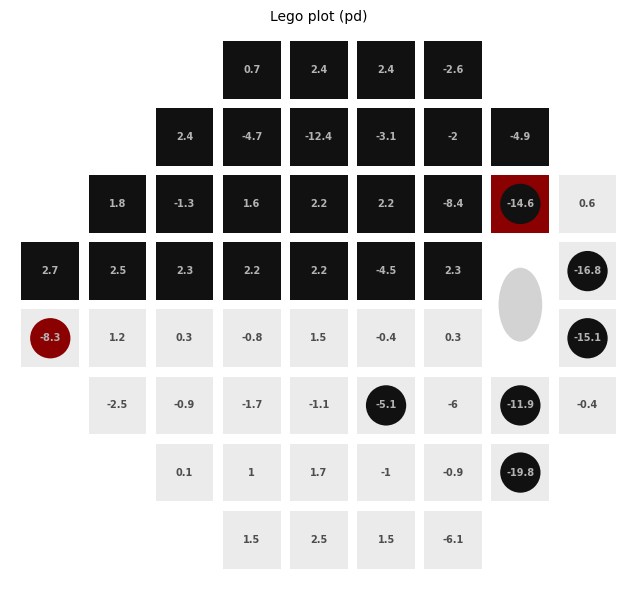

In [12]:
from PyVisualFields import visualFields
from PyVisualFields.utils import vf_blocks, missing_blocks
from PyVisualFields.utils import compute_missing_blocks
from PyVisualFields.utils import canonicalize_vf_df, canonicalize_vf_row

"""For TD/PD, this function averages the already-computed TD/PD blocks. 
This may differ slightly from older behavior that recomputed TD/PD after averaging sensitivities."""

df_VFs_py = canonicalize_vf_df(visualFields.data_vfpwgSunyiu24d2())#df_VFs_py data is acquired using vfpwgRetest24d2() function.
df_VFs_py = compute_missing_blocks(df_VFs_py)

filter1 = df_VFs_py.patientid=='sample1'
filter2 = df_VFs_py.eyeid=='OD'
df_vf_1 = df_VFs_py.loc[ filter1 & filter2]

visualFields.vflegoplot(df_vf_1, type='s', save=True, filename='file', fmt='png') # types: s, td, pd
visualFields.vflegoplot_s(df_vf_1, save=True, filename='file', fmt='png') # alias for vflegoplot(type='s')
visualFields.vflegoplot_td(df_vf_1, save=True, filename='file', fmt='png') # alias for vflegoplot(type='td')
visualFields.vflegoplot_pd(df_vf_1, save=True, filename='file', fmt='png') # alias for vflegoplot(type='pd')


